## Rumusan Masalah

Tingginya biaya operasional logistik yang tidak dibarengi dengan transparansi efisiensi vendor, sehingga perusahaan berisiko membayar mahal untuk layanan yang tidak optimal (inefisiensi biaya)

## Hipotesa
1. Terdapat variasi tarif yang signifikan antar vendor untuk segmen pengiriman yang sama (Jarak & Berat), yang menunjukkan adanya potensi overpricing pada vendor tertentu?
2. Pengiriman jarak pendek memiliki biaya per KM yang lebih tinggi dibandingkan jarak jauh karena adanya kebijakan fixed cost atau minimum charge dari vendor?
3. Penggunaan kendaraan listrik (EV) memberikan biaya operasional yang lebih rendah dibandingkan kendaraan konvensional (bahan bakar fosil)?
4. Vendor dengan tarif yang lebih mahal memiliki tingkat keterlambatan (delay rate) yang lebih rendah dan rating yang lebih tinggi (Ada harga, ada rupa)?
5. Kondisi cuaca ekstrem (Stormy/Rainy) secara signifikan meningkatkan probabilitas keterlambatan pengiriman pada semua vendor?
6. Mode pengiriman Same Day memiliki risiko keterlambatan yang lebih tinggi dibandingkan mode Standard?
7. Tidak semua vendor yang dominan (sering digunakan) merupakan vendor yang paling efisien secara biaya dan waktu?
8. Paket dengan berat rendah (Light Weight) memiliki efisiensi biaya per KG yang paling buruk bagi perusahaan?

# Prepare Data

**Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu

**Import Dataset**

In [2]:
df = pd.read_csv('Delivery_Logistics.csv')
df_cleaned = df.copy()

df_cleaned

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24750.01,dhl,furniture,scooter,two day,east,foggy,80.7,3.65,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000016,no,delivered,5,414.4500
24996,24750.01,ecom express,automobile parts,ev van,standard,west,clear,172.9,21.42,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000024,no,delivered,5,928.7600
24997,24750.01,ekart,clothing,scooter,same day,east,rainy,168.4,4.85,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000008,yes,delayed,2,956.5500
24998,24750.01,shadowfax,documents,ev van,standard,west,stormy,37.2,8.04,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000024,no,delivered,5,210.1200


**Cek DataType**

In [3]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


**Konversi Type Data**

In [4]:
df_cleaned['delivery_time_hours'] = pd.to_datetime(df_cleaned['delivery_time_hours']).dt.nanosecond
df_cleaned['expected_time_hours'] = pd.to_datetime(df_cleaned['expected_time_hours']).dt.nanosecond
df_cleaned['delivery_cost'] = df_cleaned['delivery_cost'].round(2)

**Create Kolom Baru**

In [5]:
df_cleaned['is_delayed'] = df_cleaned['delayed'].map({'yes': 1, 'no': 0})
df_cleaned['cost_per_km'] = df_cleaned['delivery_cost'] / df_cleaned['distance_km']
df_cleaned['cost_per_kg'] = df_cleaned['delivery_cost'] / df_cleaned['package_weight_kg']
df_cleaned['cost_per_unit'] = df_cleaned['cost_per_km'] * df_cleaned['package_weight_kg']
df_cleaned['gap_time_delivery'] = df_cleaned['delivery_time_hours'] - df_cleaned['expected_time_hours']

**Cek value kosong**

In [6]:
df_cleaned.isnull().sum()

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
is_delayed             0
cost_per_km            0
cost_per_kg            0
cost_per_unit          0
gap_time_delivery      0
dtype: int64

**Cek Value Duplikat**

In [7]:
identict_duplicated = df_cleaned[df_cleaned.duplicated(keep=False)]
id_duplicated = df_cleaned[df_cleaned.duplicated(subset=['delivery_id'], keep=False)]

print(f"Jumlah baris yang identik : {len (identict_duplicated)}")
print(f"Jumlah baris dengan ID sama: {len(id_duplicated)}")

Jumlah baris yang identik : 0
Jumlah baris dengan ID sama: 500


**Cek isi baris pada kolom bertype object**

In [8]:
for col in df_cleaned.select_dtypes(include='object').columns:
    print(f"\n{col}:", df_cleaned[col].unique())


delivery_partner: ['delhivery' 'xpressbees' 'shadowfax' 'dhl' 'amazon logistics' 'blue dart'
 'fedex' 'ecom express' 'ekart']

package_type: ['automobile parts' 'cosmetics' 'groceries' 'electronics' 'clothing'
 'documents' 'fragile items' 'pharmacy' 'furniture']

vehicle_type: ['bike' 'ev van' 'truck' 'van' 'ev bike' 'scooter']

delivery_mode: ['same day' 'express' 'two day' 'standard']

region: ['west' 'central' 'east' 'north' 'south']

weather_condition: ['clear' 'cold' 'rainy' 'foggy' 'hot' 'stormy']

delayed: ['no' 'yes']

delivery_status: ['delivered' 'delayed' 'failed']


**Cek data statistik dasar**

In [9]:
df_cleaned.describe()

,delivery_id,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost,is_delayed,cost_per_km,cost_per_kg,cost_per_unit,gap_time_delivery
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,6.248040,13.107680,3.666000,864.944599,0.266760,7.041306,81.742865,187.377347,-6.859640
std,7212.732314,86.409745,14.368663,3.140935,7.559024,1.149964,435.712537,0.442275,5.004048,182.327259,211.109255,8.069482
min,250.990000,3.600000,0.670000,0.000000,2.000000,1.000000,95.670000,0.000000,5.002579,3.104515,3.351728,-24.000000
25%,6250.750000,75.900000,12.680000,4.000000,8.000000,3.000000,490.800000,0.000000,5.420741,19.686678,73.983992,-14.000000
50%,12500.500000,151.000000,25.145000,6.000000,8.000000,4.000000,867.535000,0.000000,5.744712,34.272263,155.079274,-6.000000
75%,18750.250000,224.900000,37.660000,8.000000,16.000000,5.000000,1237.910000,1.000000,6.494886,65.230630,243.414774,0.000000
max,24750.010000,297.100000,49.520000,19.000000,24.000000,5.000000,1632.720000,1.000000,73.491667,2344.626866,3615.055083,12.000000


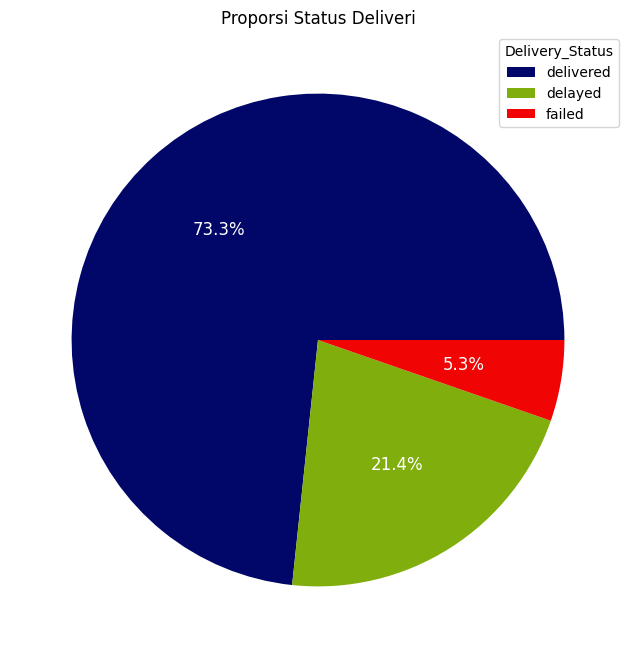

In [10]:
proporsi_deliv_status = df_cleaned['delivery_status'].value_counts(normalize=True)*100

label = proporsi_deliv_status.index

plt.figure(figsize=(8, 8))
plt.pie(
    proporsi_deliv_status,
    labels=label,
    autopct='%1.1f%%',
    colors=['#010768',"#80ae0d","#f00404" ],
    textprops={'color': 'white', 'fontsize': 12}
)

plt.title('Proporsi Status Deliveri')
plt.legend(
    labels = label,
    loc='best',  
    title='Delivery_Status'
)

plt.show()

In [11]:
total_trx = len(df_cleaned)
total_yes = (df_cleaned['is_delayed'] == 1).sum()
total_no = (df_cleaned['is_delayed'] == 0).sum()

print(f"Total Transaksi : {total_trx}")
print(f"Total Delay (Yes) : {total_yes}")
print(f"Total Delay (No) : {total_no}")

Total Transaksi : 25000
Total Delay (Yes) : 6669
Total Delay (No) : 18331


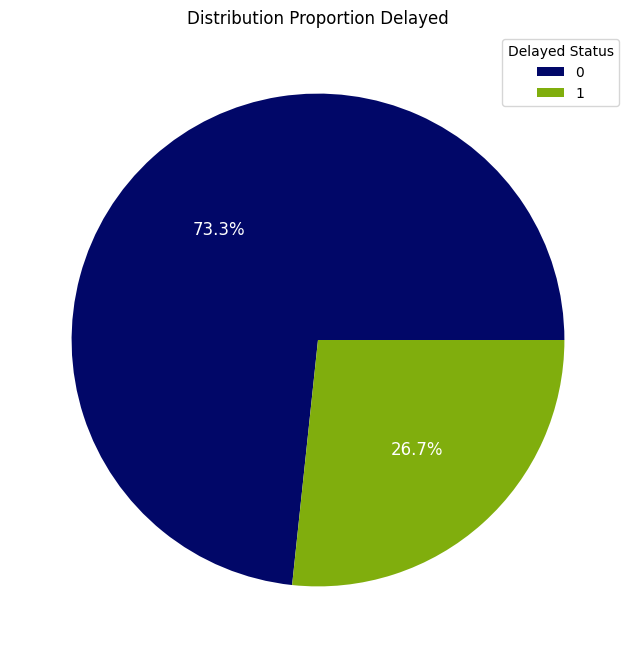

In [12]:
delayed_percentage = df_cleaned['is_delayed'].value_counts(normalize=True)*100

label = delayed_percentage.index

plt.figure(figsize=(8, 8))
plt.pie(
    delayed_percentage,
    labels=label,
    autopct='%1.1f%%',
    colors=['#010768', "#80ae0d"],
    textprops={'color': 'white', 'fontsize': 12}
)

plt.title('Distribution Proportion Delayed')
plt.legend(
    labels = label,
    loc='best',  
    title='Delayed Status'
)

plt.show()

# EDA

## Univariat

**By Delivery Partner**

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\453283424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


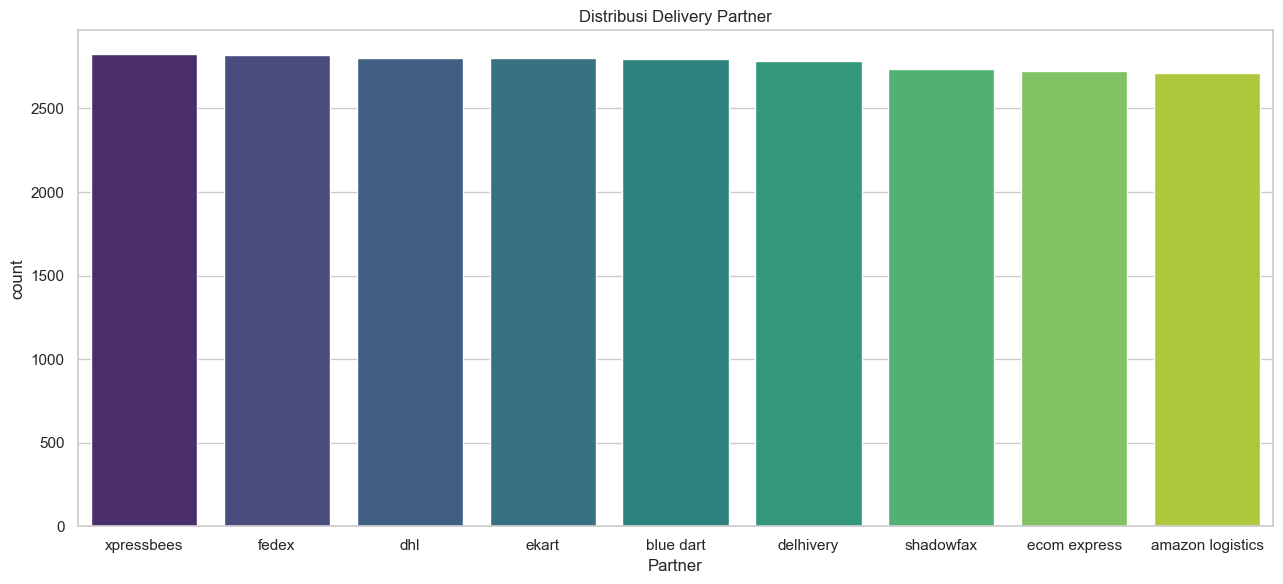

Ditribui Delivery Partner
   delivery_partner  count
0        xpressbees   2826
1             fedex   2818
2               dhl   2802
3             ekart   2801
4         blue dart   2798
5         delhivery   2786
6         shadowfax   2736
7      ecom express   2722
8  amazon logistics   2711


In [13]:
dist_delvpart = df_cleaned['delivery_partner'].value_counts().reset_index()

sns.set(style='whitegrid')
plt.figure(figsize=(13, 6))
sns.barplot(
    data=dist_delvpart,
    x='delivery_partner',
    y='count',
    palette='viridis'
)

plt.title('Distribusi Delivery Partner')
plt.xlabel('Partner')
plt.tight_layout()
plt.show()

print('Ditribui Delivery Partner')
print(dist_delvpart)

**By Vihicle Type**

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\66367883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


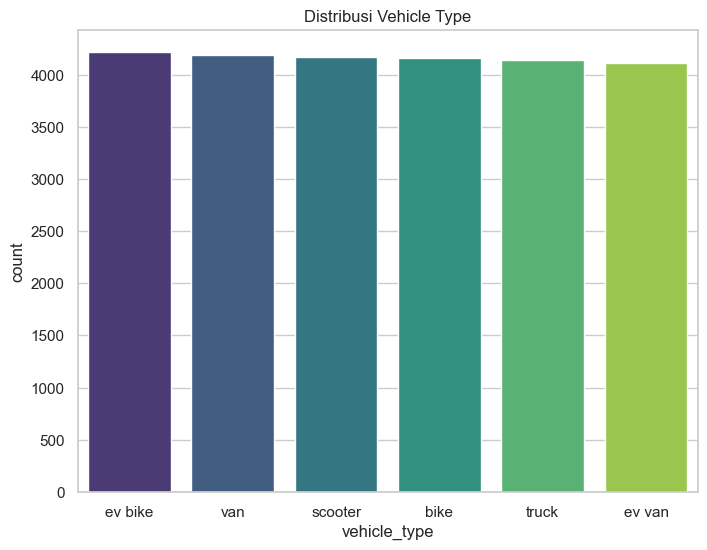

In [14]:
dist_vehictype = df_cleaned['vehicle_type'].value_counts().reset_index()

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.barplot(
    data=dist_vehictype,
    x = 'vehicle_type',
    y = 'count',
    palette= 'viridis'
)

plt.title('Distribusi Vehicle Type')
plt.show()

**By Delivery Mode**

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\3692125979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


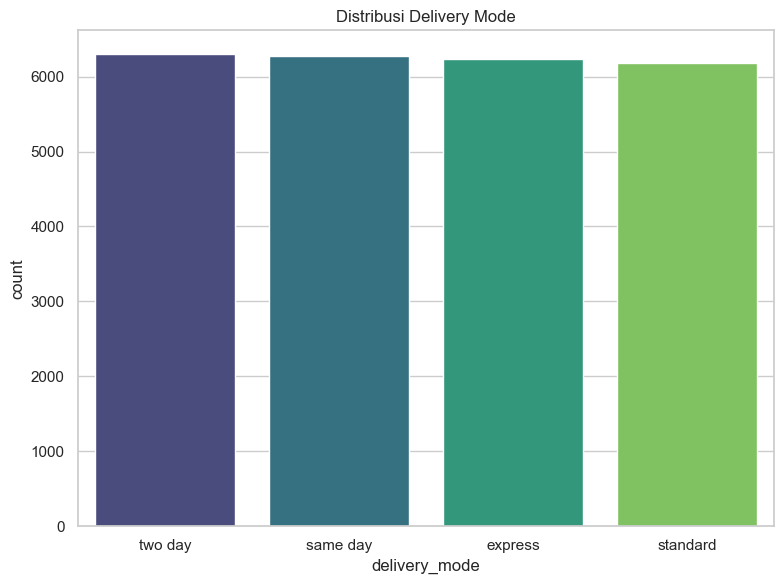

Distribusi Delivery Mode
  delivery_mode  count
0       two day   6302
1      same day   6279
2       express   6233
3      standard   6186


In [15]:
dist_delvmode = df_cleaned['delivery_mode'].value_counts().reset_index()

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.barplot(
    data=dist_delvmode,
    x= 'delivery_mode',
    y= 'count',
    palette= 'viridis'
)

plt.title('Distribusi Delivery Mode')
plt.tight_layout()
plt.show()

print('Distribusi Delivery Mode')
print(dist_delvmode)

**By Cost, distance, weight**

In [16]:
# Cek kemiringan (Skewness)
print(f"Skewness Biaya: {df_cleaned['delivery_cost'].skew():.2f}")
print(f"Skewness Jarak: {df_cleaned['distance_km'].skew():.2f}")
print(f"Skewness Berat: {df_cleaned['package_weight_kg'].skew():.2f}")


Skewness Biaya: 0.00
Skewness Jarak: 0.00
Skewness Berat: -0.00


Berdasarkan hasil skewnessnya, dipastikan bahwa data tersebut terdistribusi normal dan untuk langkah selanjutnya akan menggunakan metode CV ( Coefficient of Variation) bukan IQR Ratio

***By Delivery Cost***

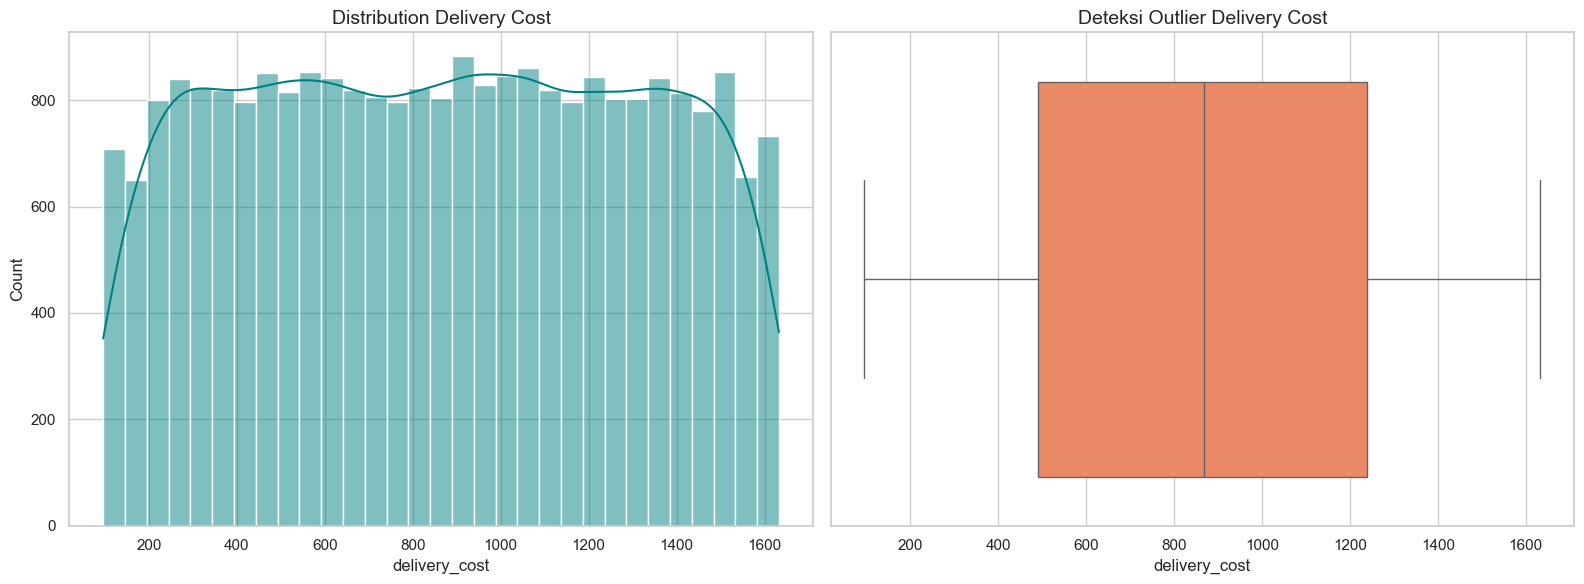

In [17]:

# Set style
sns.set_style("whitegrid")

# Membuat bagan chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram 
sns.histplot(df_cleaned['delivery_cost'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution Delivery Cost', fontsize=14)


# 2. Box Plot 
sns.boxplot(x=df_cleaned['delivery_cost'], ax=axes[1], color='coral')
axes[1].set_title('Deteksi Outlier Delivery Cost', fontsize=14)


plt.tight_layout()
plt.show()

In [18]:
# Melihat ringkasan statistik
print(df_cleaned['delivery_cost'].describe())

# Menghitung batas atas untuk outlier (Metode IQR)
Q1 = df_cleaned['delivery_cost'].quantile(0.25)
Q3 = df_cleaned['delivery_cost'].quantile(0.75)
IQR = Q3 - Q1
limit_atas = Q3 + (1.5 * IQR)

outliers_count = df_cleaned[df_cleaned['delivery_cost'] > limit_atas].shape[0]
print(f"\nBatas atas biaya normal: {limit_atas:.2f}")
print(f"Jumlah transaksi yang dianggap outlier: {outliers_count}")


count    25000.000000
mean       864.944599
std        435.712537
min         95.670000
25%        490.800000
50%        867.535000
75%       1237.910000
max       1632.720000
Name: delivery_cost, dtype: float64

Batas atas biaya normal: 2358.58
Jumlah transaksi yang dianggap outlier: 0


Berdasarkan visualisasi histogram dan boxplot, distribusi delivery cost relatif merata dan tidak menunjukkan adanya outlier berdasarkan metode IQR

**Buat ambang batas (P90)**

In [19]:
# 1. Hitung nilai ambang batas P90
p90_threshold = df_cleaned['delivery_cost'].quantile(0.90)

# 2. Buat kolom flag (Tanda)
df_cleaned['is_p90_high_cost'] = df_cleaned['delivery_cost'] >= p90_threshold

print(f"Batas Biaya P90: {p90_threshold:.2f}")
print(f"Jumlah transaksi masuk kategori 10% termahal: {df_cleaned['is_p90_high_cost'].sum()}")

Batas Biaya P90: 1467.80
Jumlah transaksi masuk kategori 10% termahal: 2500


Karena tidak ditemukan data outlier, kita membuat ambang batas P90 yang mana itu untuk menentukan 10% harga termahal

Biaya 10% termahal ada di $1.467,80 dengan 2.500 transaksi

***Distance (Km) & Weight package (Kg)***

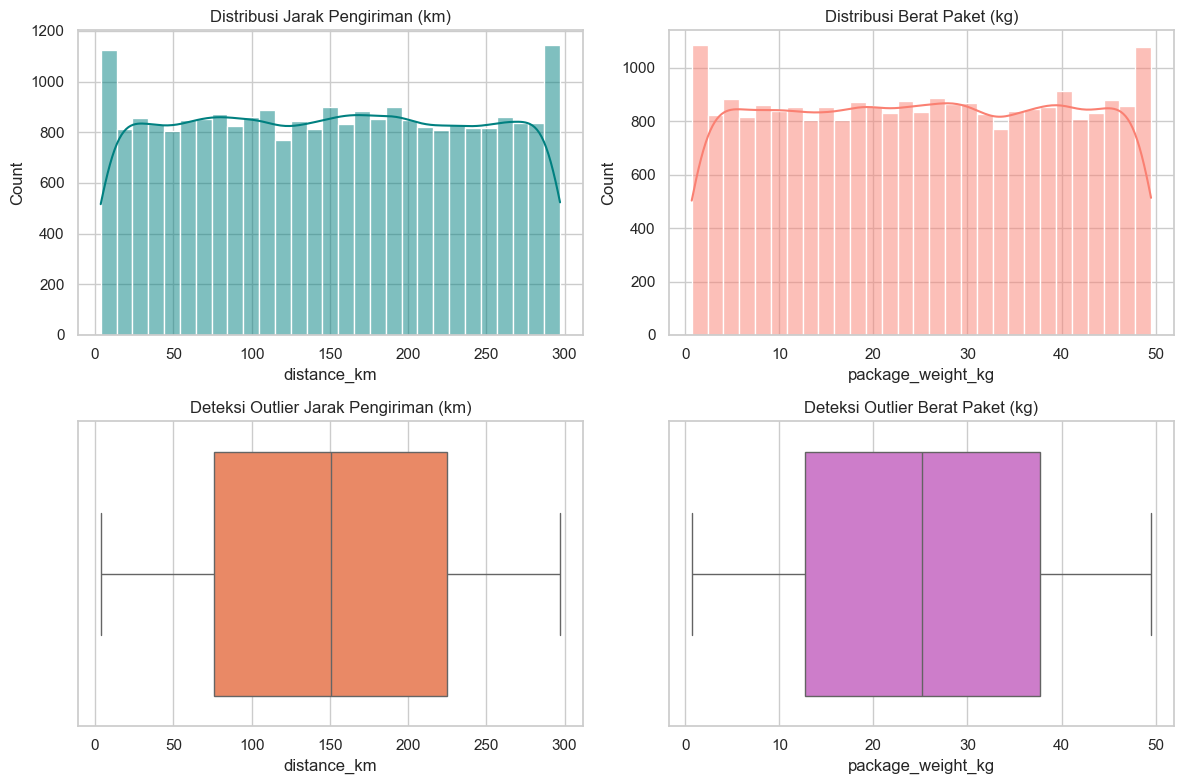

In [20]:

# Set Style
sns.set_style("whitegrid")

# Membuat Bagan
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# Histogram Distance (km)
sns.histplot(df_cleaned['distance_km'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribusi Jarak Pengiriman (km)')

# [0, 1] Histogram Package Weight (kg) - Kanan Atas
sns.histplot(df_cleaned['package_weight_kg'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribusi Berat Paket (kg)')

# --- BARIS 2 ---

# [1, 0] Histogram Delivery Cost - Kiri Bawah
sns.boxplot(x=df_cleaned['distance_km'], ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Deteksi Outlier Jarak Pengiriman (km)')

# [1, 1] Histogram Delivery Rating - Kanan Bawah
# Pakai discrete=True karena rating biasanya angka bulat 1-5
sns.boxplot(x=df_cleaned['package_weight_kg'], ax=axes[1, 1], color='orchid')
axes[1, 1].set_title('Deteksi Outlier Berat Paket (kg)')

# Mengatur jarak agar label tidak bertabrakan
plt.tight_layout()
plt.show()



***Ringkasan Statistik Jarak Pengiriman (km)***

In [21]:
# Melihat ringkasan statistik
print(df_cleaned['distance_km'].describe())

# Menghitung batas atas untuk outlier (Metode IQR)
Q1 = df_cleaned['distance_km'].quantile(0.25)
Q3 = df_cleaned['distance_km'].quantile(0.75)
IQR = Q3 - Q1
limit_atas = Q3 + (1.5 * IQR)

outliers_count = df_cleaned[df_cleaned['distance_km'] > limit_atas].shape[0]
print(f"\nBatas atas biaya normal: {limit_atas:.2f}")
print(f"Jumlah transaksi yang dianggap outlier: {outliers_count}")

count    25000.000000
mean       150.390436
std         86.409745
min          3.600000
25%         75.900000
50%        151.000000
75%        224.900000
max        297.100000
Name: distance_km, dtype: float64

Batas atas biaya normal: 448.40
Jumlah transaksi yang dianggap outlier: 0


***Pembuatan segment pada jarak***

In [22]:
bins = [
    df_cleaned['distance_km'].min(),
    df_cleaned['distance_km'].quantile(0.25),
    df_cleaned['distance_km'].quantile(0.50),
    df_cleaned['distance_km'].quantile(0.75),
    df_cleaned['distance_km'].max()
]

df_cleaned['distance_segment'] = pd.cut(
    df_cleaned['distance_km'],
    bins=bins,
    include_lowest=True,
    labels=['Short', 'Mid', 'Long', 'Ultra Long']
)

df_cleaned['distance_segment'].value_counts()


distance_segment
Short         6257
Long          6257
Mid           6244
Ultra Long    6242
Name: count, dtype: int64

Pemilihan pembuatan segmentasi menggunakan quantile dikarenakan data terdistribusi normal pada uji skewness sebelumnya

***Ringkasan Statistik Berat Paket (kg)***

In [23]:
# Melihat ringkasan statistik
print(df_cleaned['package_weight_kg'].describe())

# Menghitung batas atas untuk outlier (Metode IQR)
Q1 = df_cleaned['package_weight_kg'].quantile(0.25)
Q3 = df_cleaned['package_weight_kg'].quantile(0.75)
IQR = Q3 - Q1
limit_atas = Q3 + (1.5 * IQR)

outliers_count = df_cleaned[df_cleaned['package_weight_kg'] > limit_atas].shape[0]
print(f"\nBatas atas biaya normal: {limit_atas:.2f}")
print(f"Jumlah transaksi yang dianggap outlier: {outliers_count}")


count    25000.000000
mean        25.145898
std         14.368663
min          0.670000
25%         12.680000
50%         25.145000
75%         37.660000
max         49.520000
Name: package_weight_kg, dtype: float64

Batas atas biaya normal: 75.13
Jumlah transaksi yang dianggap outlier: 0


***Pembuatan sementasi pada berat paket***

In [24]:
bins = [
    df_cleaned['package_weight_kg'].min(),
    df_cleaned['package_weight_kg'].quantile(0.25),
    df_cleaned['package_weight_kg'].quantile(0.50),
    df_cleaned['package_weight_kg'].quantile(0.75),
    df_cleaned['package_weight_kg'].max()
]

df_cleaned['weight_segment'] = pd.cut(
    df_cleaned['package_weight_kg'],
    bins=bins,
    include_lowest=True,
    labels=['Light', 'Mid', 'Heavy', 'Very Heavy']
)

df_cleaned['weight_segment'].value_counts()

weight_segment
Heavy         6253
Light         6251
Mid           6249
Very Heavy    6247
Name: count, dtype: int64

***Cost/km, Cost/kg, Cost/unit***

In [25]:
# Cek kemiringan (Skewness)
print(f"Skewness Biaya: {df_cleaned['cost_per_kg'].skew():.2f}")
print(f"Skewness Jarak: {df_cleaned['cost_per_km'].skew():.2f}")
print(f"Skewness Berat: {df_cleaned['cost_per_unit'].skew():.2f}")


Skewness Biaya: 6.41
Skewness Jarak: 6.38
Skewness Berat: 5.82


Berbeda dengan data Cost sebelumnya, pada metrik untuk melihat efisiensi ini menunjukkan distribusi positive skew yang ekstrem

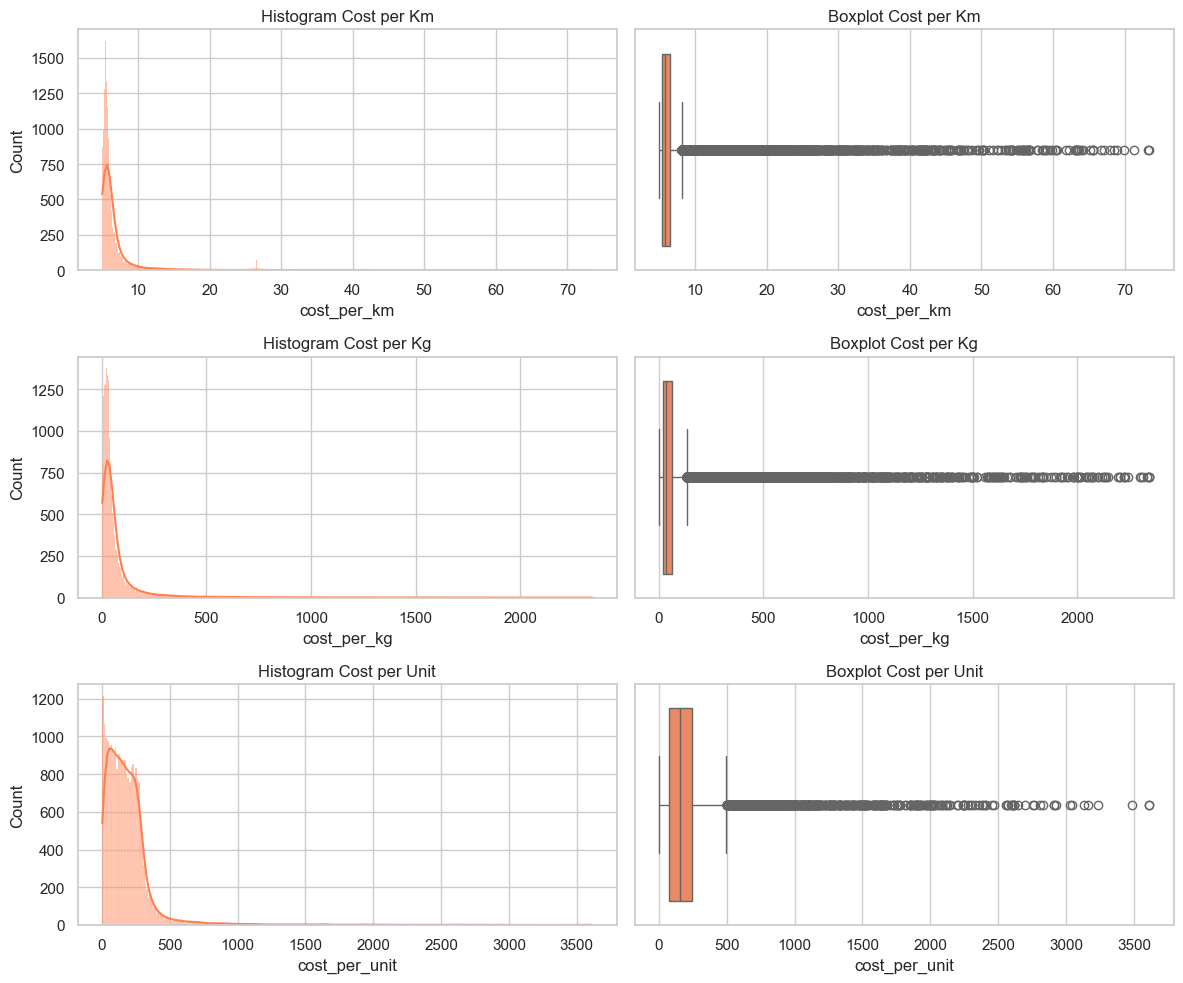

In [26]:
# Set Style
sns.set_style('whitegrid')

# Membuat Bagan Chart
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Histogram Harga per Km
sns.histplot(df_cleaned['cost_per_km'], kde=True, ax=axes[0, 0], color='coral')
axes[0, 0].set_title("Histogram Cost per Km")

# Box Plot Harga per Km
sns.boxplot(x=df_cleaned['cost_per_km'], ax=axes[0, 1], color='coral')
axes[0, 1].set_title("Boxplot Cost per Km")

# Histogram Harga per Kg
sns.histplot(df_cleaned['cost_per_kg'], kde=True, ax=axes[1, 0], color='coral')
axes[1, 0].set_title("Histogram Cost per Kg")

# Box Plot Harga per Kg
sns.boxplot(x=df_cleaned['cost_per_kg'], ax=axes[1, 1], color='coral')
axes[1, 1].set_title("Boxplot Cost per Kg")

# Histogram Harga per Unit
sns.histplot(df_cleaned['cost_per_unit'], kde=True, ax=axes[2, 0], color='coral')
axes[2, 0].set_title("Histogram Cost per Unit")

# Box Plot Harga per Unit
sns.boxplot(x=df_cleaned['cost_per_unit'], ax=axes[2, 1], color='coral')
axes[2, 1].set_title("Boxplot Cost per Unit")

plt.tight_layout()
plt.show()


***Ringkasan Biaya/km***

In [27]:
# Melihat ringkasan statistik
print(df_cleaned['cost_per_km'].describe())

# Menghitung batas atas untuk outlier (Metode IQR)
Q1 = df_cleaned['cost_per_km'].quantile(0.25)
Q3 = df_cleaned['cost_per_km'].quantile(0.75)
IQR_km = Q3 - Q1
limit_atas = Q3 + (1.5 * IQR_km)

outliers_count = df_cleaned[df_cleaned['cost_per_km'] > limit_atas].shape[0]
print(f"\nBatas atas biaya normal: {limit_atas:.2f}")
print(f"Jumlah transaksi yang dianggap outlier: {outliers_count}")


count    25000.000000
mean         7.041306
std          5.004048
min          5.002579
25%          5.420741
50%          5.744712
75%          6.494886
max         73.491667
Name: cost_per_km, dtype: float64

Batas atas biaya normal: 8.11
Jumlah transaksi yang dianggap outlier: 3010


***Ringkasan Biaya/kg***

In [28]:
# Melihat ringkasan statistik
print(df_cleaned['cost_per_kg'].describe())

# Menghitung batas atas untuk outlier (Metode IQR)
Q1 = df_cleaned['cost_per_kg'].quantile(0.25)
Q3 = df_cleaned['cost_per_kg'].quantile(0.75)
IQR_kg = Q3 - Q1
limit_atas = Q3 + (1.5 * IQR_kg)

outliers_count = df_cleaned[df_cleaned['cost_per_kg'] > limit_atas].shape[0]
print(f"\nBatas atas biaya normal: {limit_atas:.2f}")
print(f"Jumlah transaksi yang dianggap outlier: {outliers_count}")


count    25000.000000
mean        81.742865
std        182.327259
min          3.104515
25%         19.686678
50%         34.272263
75%         65.230630
max       2344.626866
Name: cost_per_kg, dtype: float64

Batas atas biaya normal: 133.55
Jumlah transaksi yang dianggap outlier: 2940


***Ringkasan Biaya/unit***

In [29]:
# Melihat ringkasan statistik
print(df_cleaned['cost_per_unit'].describe())

# Menghitung batas atas untuk outlier (Metode IQR)
Q1 = df_cleaned['cost_per_unit'].quantile(0.25)
Q3 = df_cleaned['cost_per_unit'].quantile(0.75)
IQR_unit = Q3 - Q1
limit_atas = Q3 + (1.5 * IQR_unit)

outliers_count = df_cleaned[df_cleaned['cost_per_unit'] > limit_atas].shape[0]
print(f"\nBatas atas biaya normal: {limit_atas:.2f}")
print(f"Jumlah transaksi yang dianggap outlier: {outliers_count}")


count    25000.000000
mean       187.377347
std        211.109255
min          3.351728
25%         73.983992
50%        155.079274
75%        243.414774
max       3615.055083
Name: cost_per_unit, dtype: float64

Batas atas biaya normal: 497.56
Jumlah transaksi yang dianggap outlier: 894


***Ringkasan variabilitas relatif pada Biaya***

In [30]:
# Metrik Operational ( menggunakan IQR Ratio )
r_delvcost = (df_cleaned['delivery_cost'].std() / df_cleaned['delivery_cost'].mean()) * 100
r_distance = (df_cleaned['distance_km'].std() / df_cleaned['distance_km'].mean()) * 100
r_packweight = (df_cleaned['package_weight_kg'].std() / df_cleaned['package_weight_kg'].mean()) * 100

# Metrik Efisiensi ( Menggunakan Coefficient of Variation )

r_costkm = (IQR_km / df_cleaned['cost_per_km'].median()) *100
r_costkg = (IQR_kg / df_cleaned['cost_per_kg'].median()) *100
r_costunit = (IQR_unit / df_cleaned['cost_per_unit'].median()) *100

print(r_distance)
print(r_delvcost)
print(r_packweight)
print(r_costkm)
print(r_costkg)
print(r_costunit)

57.456941837034634
50.37461790223469
57.141181471117854
18.697976888844437
132.88866492032042
109.25430463264954


Secara operasional, biaya pengiriman cenderung lebih stabil dibandingkan fluktuasi jarak dan berat (CV Cost < CV Distance). Namun, saat dibedah menggunakan metrik efisiensi, ditemukan inkonsistensi harga yang sangat tinggi pada biaya per kilogram (132.88%) dan biaya per unit (109.25%)

**By Cuaca**

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\1156287842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


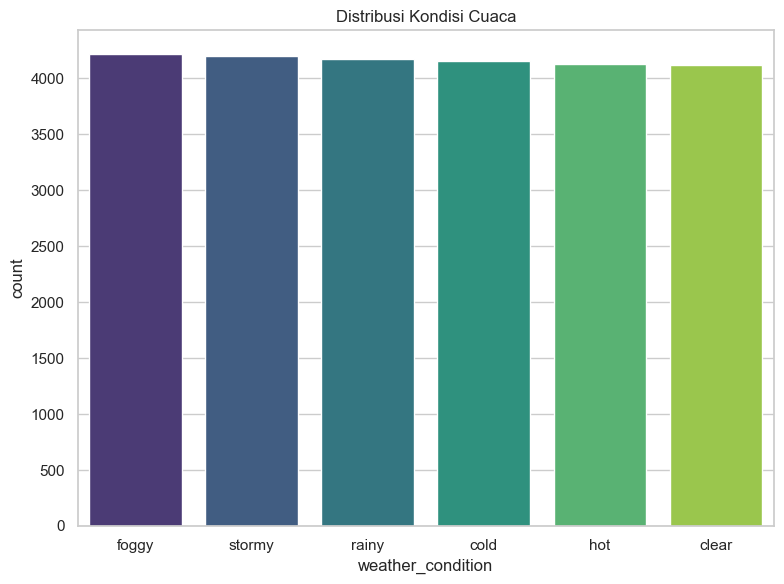

In [31]:
dist_weather = df_cleaned['weather_condition'].value_counts().reset_index()

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.barplot(
    data=dist_weather,
    x='weather_condition',
    y= 'count',
    palette= 'viridis'
)

plt.title('Distribusi Kondisi Cuaca')
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\803151783.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


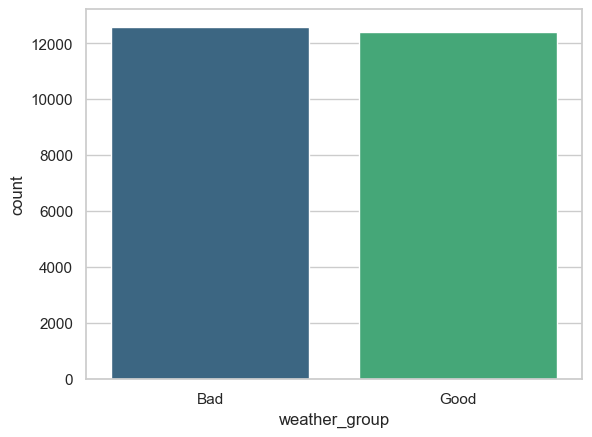

,weather_group,count
0,Bad,12588
1,Good,12412


In [32]:
# Buat group cuaca
mapping = {'foggy': 'Bad', 'rainy': 'Bad', 'stormy': 'Bad','cold': 'Good','hot': 'Good','clear': 'Good'}
df_cleaned['weather_group'] = df_cleaned['weather_condition'].map(mapping)

weather_segment = df_cleaned['weather_group'].value_counts().reset_index()

sns.set(style=('whitegrid'))
plt.Figure(figsize=(8, 6))
sns.barplot(
    data=weather_segment,
    x='weather_group',
    y='count',
    palette='viridis'
)
plt.show()
weather_segment

**By Delivery time**

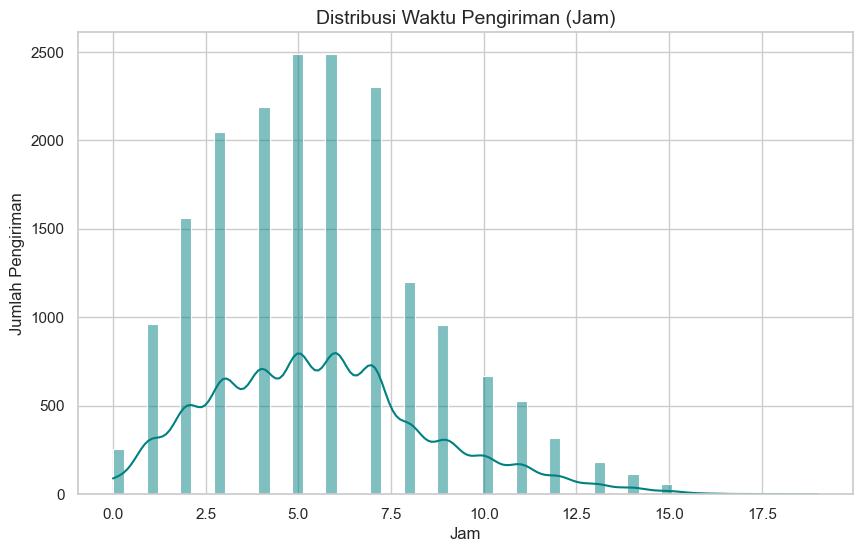

Statistik Waktu Pengiriman (Jam):
count    18331.000000
mean         5.570291
std          2.941846
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         19.000000
Name: delivery_time_hours, dtype: float64


In [33]:
# Filter status delivery
deliv_stats = df_cleaned[df_cleaned['delivery_status'] == 'delivered']

plt.figure(figsize=(10, 6))
sns.histplot(deliv_stats['delivery_time_hours'],kde=True, color='teal')
plt.title('Distribusi Waktu Pengiriman (Jam)', fontsize=14)
plt.xlabel('Jam')
plt.ylabel('Jumlah Pengiriman')
plt.show()

print("Statistik Waktu Pengiriman (Jam):")
print(deliv_stats['delivery_time_hours'].describe())

**By Rating**

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\4143778300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


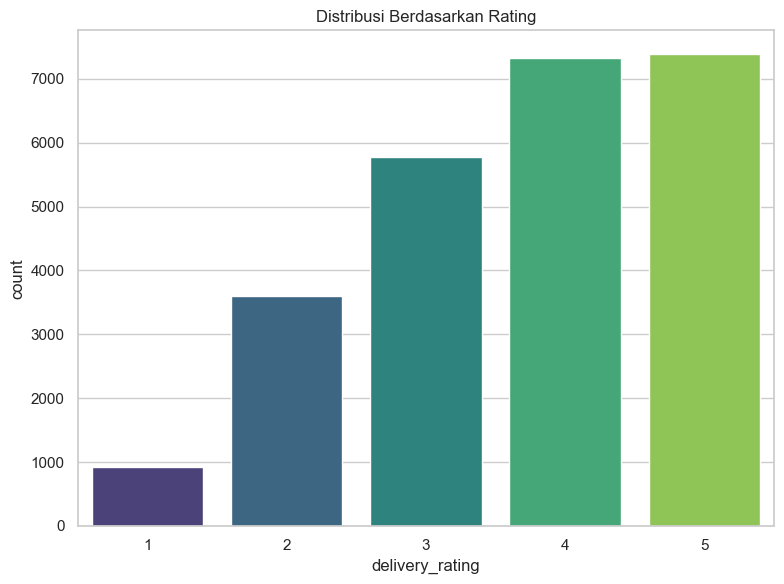

count    25000.000000
mean         3.666000
std          1.149964
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: delivery_rating, dtype: float64


In [34]:
r = df_cleaned['delivery_rating'].value_counts().reset_index()

sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.barplot(
    data=r,
    x='delivery_rating',
    y= 'count',
    palette= 'viridis'
)

plt.title('Distribusi Berdasarkan Rating')
plt.tight_layout()
plt.show()

print(df_cleaned['delivery_rating'].describe())

**By Expetasi Delivery**

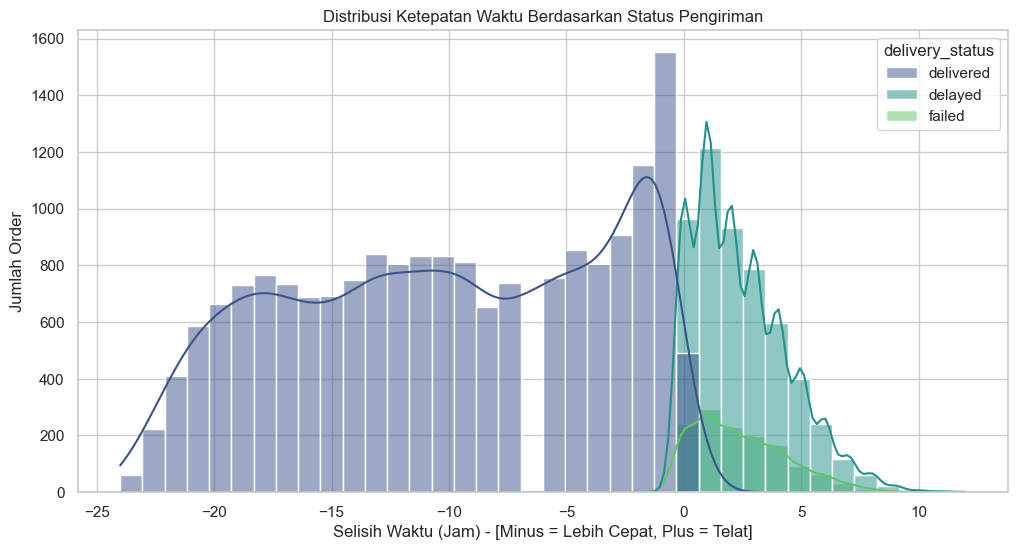

In [35]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_cleaned,
    x='gap_time_delivery',
    hue='delivery_status',
    kde=True,
    palette='viridis'
    )

plt.title('Distribusi Ketepatan Waktu Berdasarkan Status Pengiriman')
plt.xlabel('Selisih Waktu (Jam) - [Minus = Lebih Cepat, Plus = Telat]')
plt.ylabel('Jumlah Order')
plt.show()

## Bivariat

**By Vendor**

***Analisa biaya antara vendor vs segment berat***

In [36]:
# Buat table harga per vendor dengan segment berat
vendor_comparison = df_cleaned.groupby(['weight_segment', 'delivery_partner'])['cost_per_kg'].median().unstack()
print(vendor_comparison)

delivery_partner  amazon logistics   blue dart   delhivery         dhl  \
weight_segment                                                           
Light                   126.502304  126.026316  121.663102  126.998295   
Mid                      44.172877   45.089960   41.791488   48.375722   
Heavy                    28.035301   27.348922   27.654328   28.050336   
Very Heavy               22.063611   20.828815   21.005692   20.912280   

delivery_partner  ecom express       ekart       fedex   shadowfax  xpressbees  
weight_segment                                                                  
Light               126.949580  123.754968  128.293368  120.923280  126.431559  
Mid                  43.681683   45.420431   46.024691   44.865328   45.241386  
Heavy                28.892857   27.802409   27.558361   28.241815   28.281033  
Very Heavy           21.752364   22.151671   21.159204   21.833071   21.419179  


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\1182886902.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vendor_comparison = df_cleaned.groupby(['weight_segment', 'delivery_partner'])['cost_per_kg'].median().unstack()


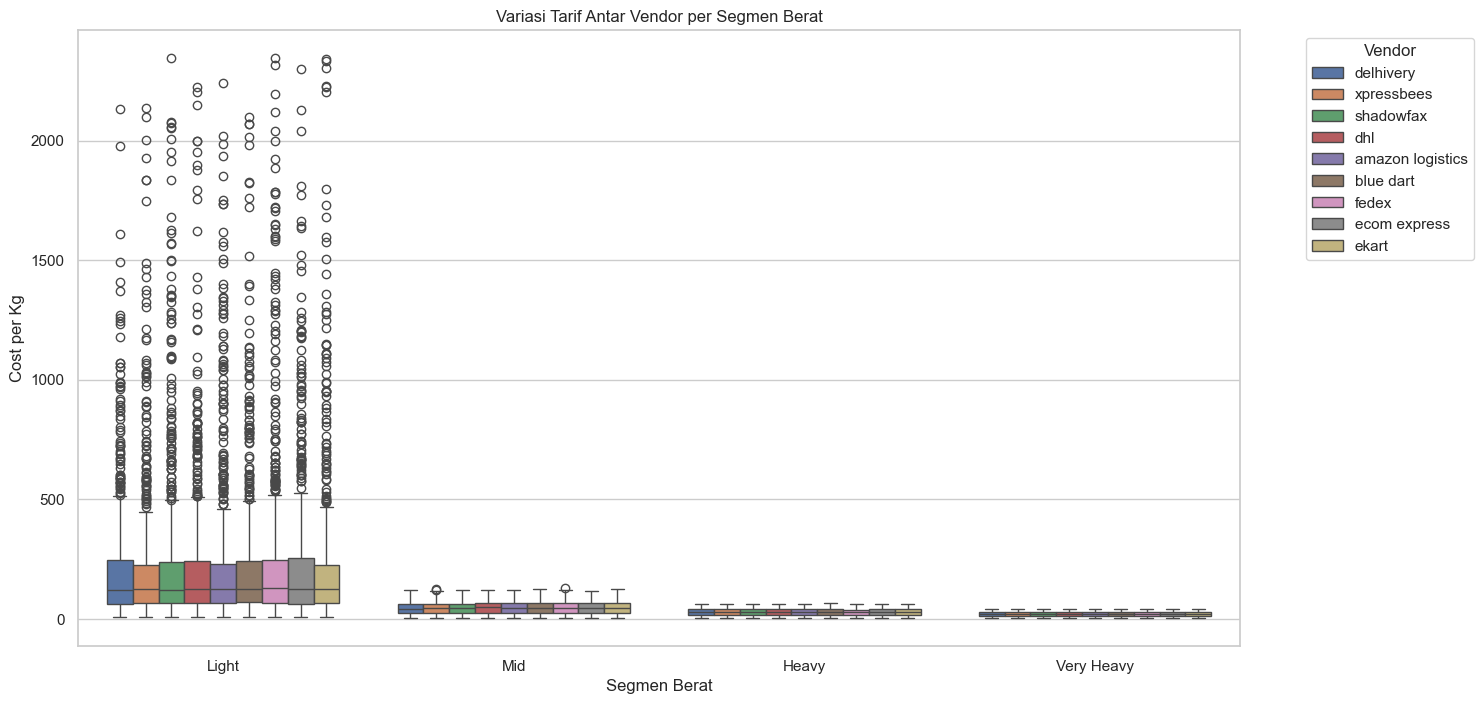

In [37]:
# Buat bagan
plt.figure(figsize=(15, 8))

# Boxplot chart
sns.boxplot(x='weight_segment', y='cost_per_kg', hue='delivery_partner', data=df_cleaned)

# Set legend
plt.title('Variasi Tarif Antar Vendor per Segmen Berat')
plt.ylabel('Cost per Kg')
plt.xlabel('Segmen Berat')
plt.legend(title='Vendor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Bisa kita lihat bahwa biaya vendor memiliki tarif flat dan juga minimum charge.

***Analisa biaya vendor vs segment jarak***

In [38]:

vendor_comparison = df_cleaned.groupby(['distance_segment', 'delivery_partner'])['cost_per_kg'].median().unstack()
print(vendor_comparison)

delivery_partner  amazon logistics  blue dart  delhivery        dhl  \
distance_segment                                                      
Short                    12.033709  11.646785  11.807958  12.094828   
Mid                      28.099602  25.743596  27.658494  27.028977   
Long                     41.106530  42.517896  40.476172  41.147083   
Ultra Long               57.537406  57.443104  55.361202  58.233291   

delivery_partner  ecom express      ekart      fedex  shadowfax  xpressbees  
distance_segment                                                             
Short                12.531928  12.325397  11.996300  12.522251   12.987854  
Mid                  26.138103  27.642005  29.228001  26.885990   25.820513  
Long                 39.682895  41.313769  42.977194  41.879873   42.259411  
Ultra Long           57.815864  57.518950  55.652189  56.170097   56.662121  


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\381941135.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vendor_comparison = df_cleaned.groupby(['distance_segment', 'delivery_partner'])['cost_per_kg'].median().unstack()


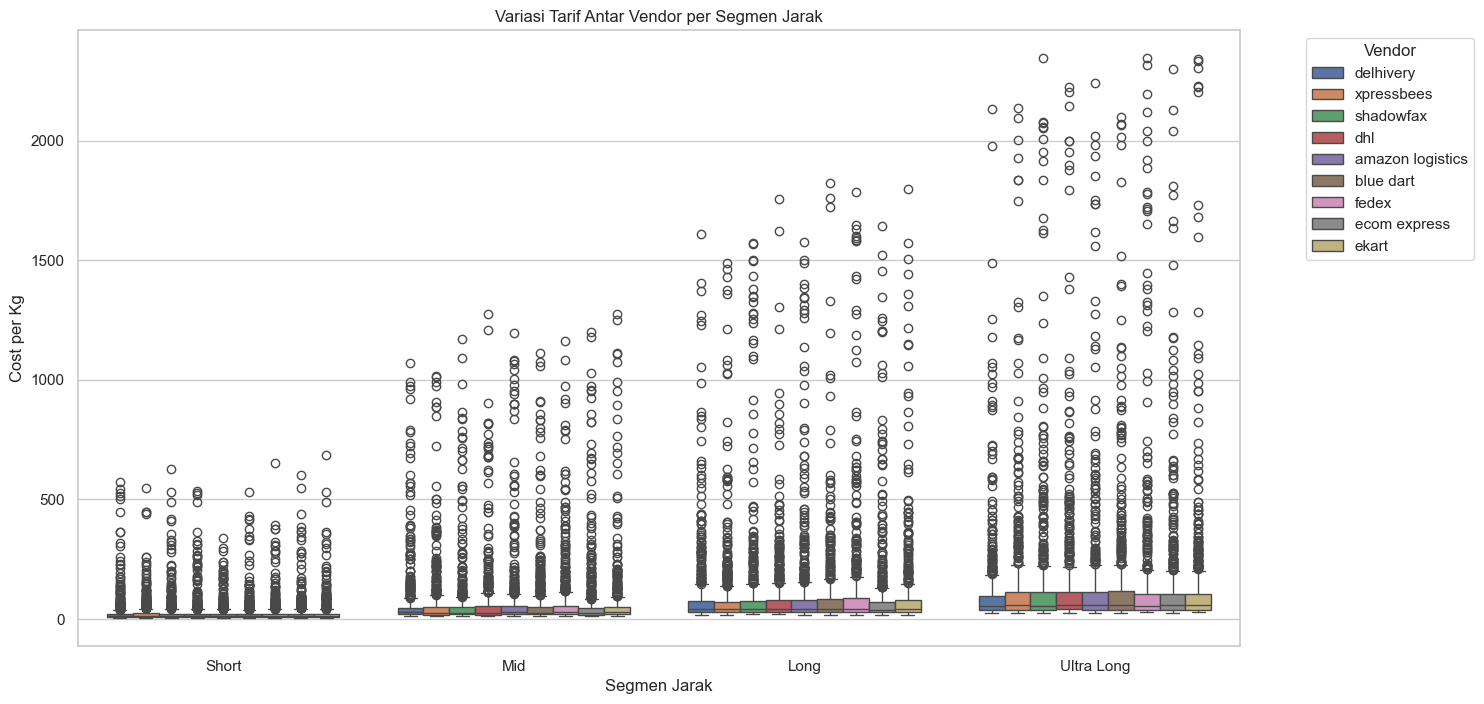

In [39]:
# Buat Bagan
plt.figure(figsize=(15, 8))

# Boxplot chart
sns.boxplot(x='distance_segment', y='cost_per_kg', hue='delivery_partner', data=df_cleaned)

# Set legend
plt.title('Variasi Tarif Antar Vendor per Segmen Jarak')
plt.ylabel('Cost per Kg')
plt.xlabel('Segmen Jarak')
plt.legend(title='Vendor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

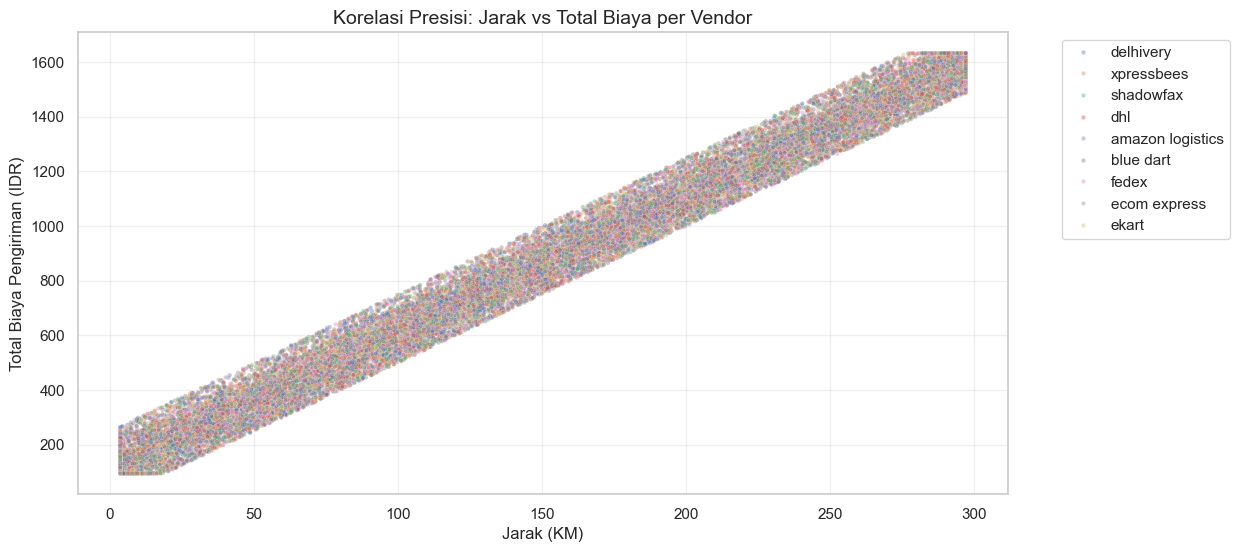

In [40]:
plt.figure(figsize=(12, 6))
# Menggunakan scatterplot untuk melihat persebaran ribuan data
sns.scatterplot(data=df_cleaned, x='distance_km', y='delivery_cost', 
                hue='delivery_partner', alpha=0.4, s=10)

plt.title('Korelasi Presisi: Jarak vs Total Biaya per Vendor', fontsize=14)
plt.xlabel('Jarak (KM)')
plt.ylabel('Total Biaya Pengiriman (IDR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

***Analisa Efisiensi Vendor***

In [41]:
# Membuat tabel ringkasan 
summary = df_cleaned.groupby('delivery_partner').agg({
    'delivery_partner': 'count',           # Dominasi (Populer)
    'cost_per_km': 'median',               # Efisiensi Biaya
    'delivery_time_hours': 'median',       # Efisiensi Waktu
    'delivery_rating': 'mean'              # Bonus: Kepuasan
}).rename(columns={'delivery_partner': 'total_orders'}).sort_values(by='total_orders', ascending=False)

print("Analisa Dominasi vs Efisiensi")
print(summary)

Analisa Dominasi vs Efisiensi
                  total_orders  cost_per_km  delivery_time_hours  \
delivery_partner                                                   
xpressbees                2826     5.748993                  6.0   
fedex                     2818     5.758384                  6.0   
dhl                       2802     5.722578                  6.0   
ekart                     2801     5.741766                  6.0   
blue dart                 2798     5.757906                  6.0   
delhivery                 2786     5.759599                  6.0   
shadowfax                 2736     5.734588                  6.0   
ecom express              2722     5.753465                  6.0   
amazon logistics          2711     5.729392                  6.0   

                  delivery_rating  
delivery_partner                   
xpressbees               3.608988  
fedex                    3.698368  
dhl                      3.685225  
ekart                    3.655480  
blue 

**Analisa tarif berat paket**

In [42]:
# Cara paling ringkas untuk melihat perbandingan antar segmen
tabel_efisien = df_cleaned.groupby('weight_segment')['delivery_cost'].describe()
tabel_efisien

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\1495612610.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabel_efisien = df_cleaned.groupby('weight_segment')['delivery_cost'].describe()


,count,mean,std,min,25%,50%,75%,max
weight_segment,,,,,,,,
Light,6251.0,805.214961,434.758340,95.67,427.480,799.47,1175.985,1628.18
Mid,6249.0,850.731879,435.532396,95.67,474.180,856.79,1222.020,1632.72
Heavy,6253.0,881.100037,433.740555,95.67,509.790,878.68,1251.390,1632.72
Very Heavy,6247.0,922.758798,430.423082,129.97,552.425,933.84,1298.220,1632.72


In [43]:
# Melihat perbandingan Mean dan Median untuk menunjukkan ketimpangan
ketimpangan_biaya = df_cleaned.groupby('weight_segment')['cost_per_kg'].agg(['mean', 'median', 'std'])

print(ketimpangan_biaya)

                      mean      median         std
weight_segment                                    
Light           230.839713  125.685714  319.387223
Mid              46.432809   44.757888   25.797357
Heavy            28.470544   27.972618   14.469721
Very Heavy       21.195395   21.405428   10.058234


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\1187899155.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ketimpangan_biaya = df_cleaned.groupby('weight_segment')['cost_per_kg'].agg(['mean', 'median', 'std'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\2140732143.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='weight_segment', y='delivery_cost', ax=axes[0], palette='Set2')
C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\2140732143.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='weight_segment', y='mean', ax=axes[1], palette='Reds_r')


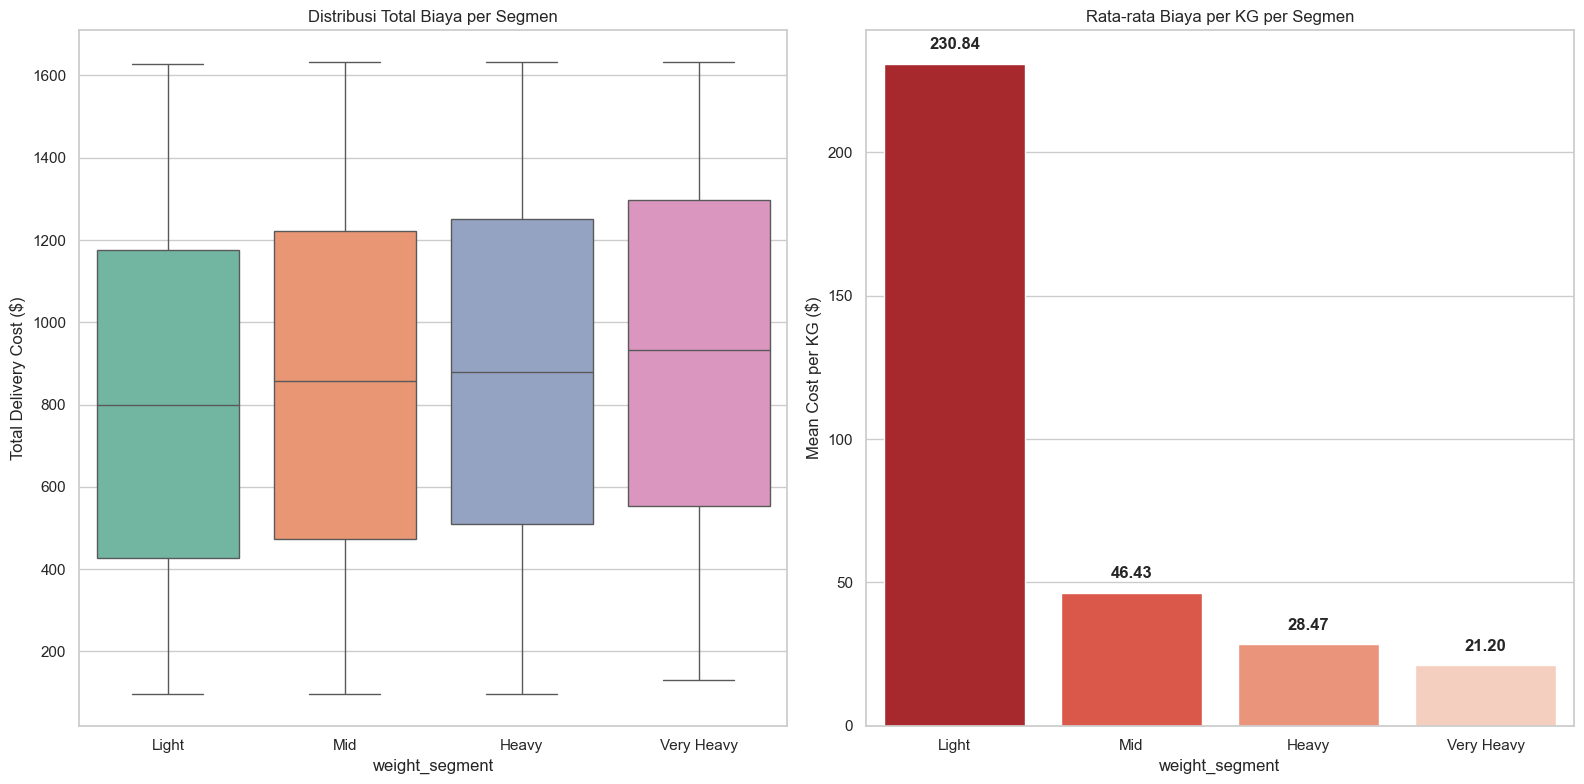

In [44]:
# Menyiapkan data dari tabel ketimpangan_biaya
plot_data = ketimpangan_biaya.reset_index()

# Buat bagan
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Boxplot 
sns.boxplot(data=df_cleaned, x='weight_segment', y='delivery_cost', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Total Biaya per Segmen')
axes[0].set_ylabel('Total Delivery Cost ($)')

# Barchart 
sns.barplot(data=plot_data, x='weight_segment', y='mean', ax=axes[1], palette='Reds_r')
axes[1].set_title('Rata-rata Biaya per KG per Segmen')
axes[1].set_ylabel('Mean Cost per KG ($)')

# Menambahkan label angka di atas bar
for i, v in enumerate(plot_data['mean']):
    axes[1].text(i, v + 5, f"{v:.2f}", ha='center', fontweight='bold')

# Mengatur tata letak agar tidak tumpang tindih
plt.tight_layout()
plt.show()

Kesimpulan :
- Pada distribusi biaya, median harga antara segment sangat tipis
- Rata rata biaya persegment pun terjadi lonjakan di segment light.

**Analisa jarak vs biaya**

In [45]:
# Cara paling ringkas untuk melihat perbandingan antar segmen
tabel_efisien = df_cleaned.groupby('distance_segment')['delivery_cost'].describe()
tabel_efisien

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\3947518330.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabel_efisien = df_cleaned.groupby('distance_segment')['delivery_cost'].describe()


,count,mean,std,min,25%,50%,75%,max
distance_segment,,,,,,,,
Short,6257.0,304.365784,121.240354,95.67,209.9200,301.520,396.2400,626.94
Mid,6244.0,678.052526,124.563880,394.44,581.8100,675.115,773.9825,995.64
Long,6257.0,1051.781621,122.824738,761.16,957.5600,1050.590,1145.3700,1363.99
Ultra Long,6242.0,1426.536477,120.976224,1136.63,1333.3175,1427.495,1523.2850,1632.72


In [46]:
# Melihat perbandingan Mean dan Median untuk menunjukkan ketimpangan
ketimpangan_biaya = df_cleaned.groupby('distance_segment')['cost_per_km'].agg(['mean', 'median', 'std'])

print(ketimpangan_biaya)

                       mean    median       std
distance_segment                               
Short             11.078852  7.970844  8.809460
Mid                6.033644  5.983520  0.595653
Long               5.616547  5.604884  0.333640
Ultra Long         5.430225  5.431849  0.228488


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\3126511956.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ketimpangan_biaya = df_cleaned.groupby('distance_segment')['cost_per_km'].agg(['mean', 'median', 'std'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\809784383.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='distance_segment', y='delivery_cost', ax=axes[0], palette='Set2')
C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\809784383.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='distance_segment', y='mean', ax=axes[1], palette='Reds_r')


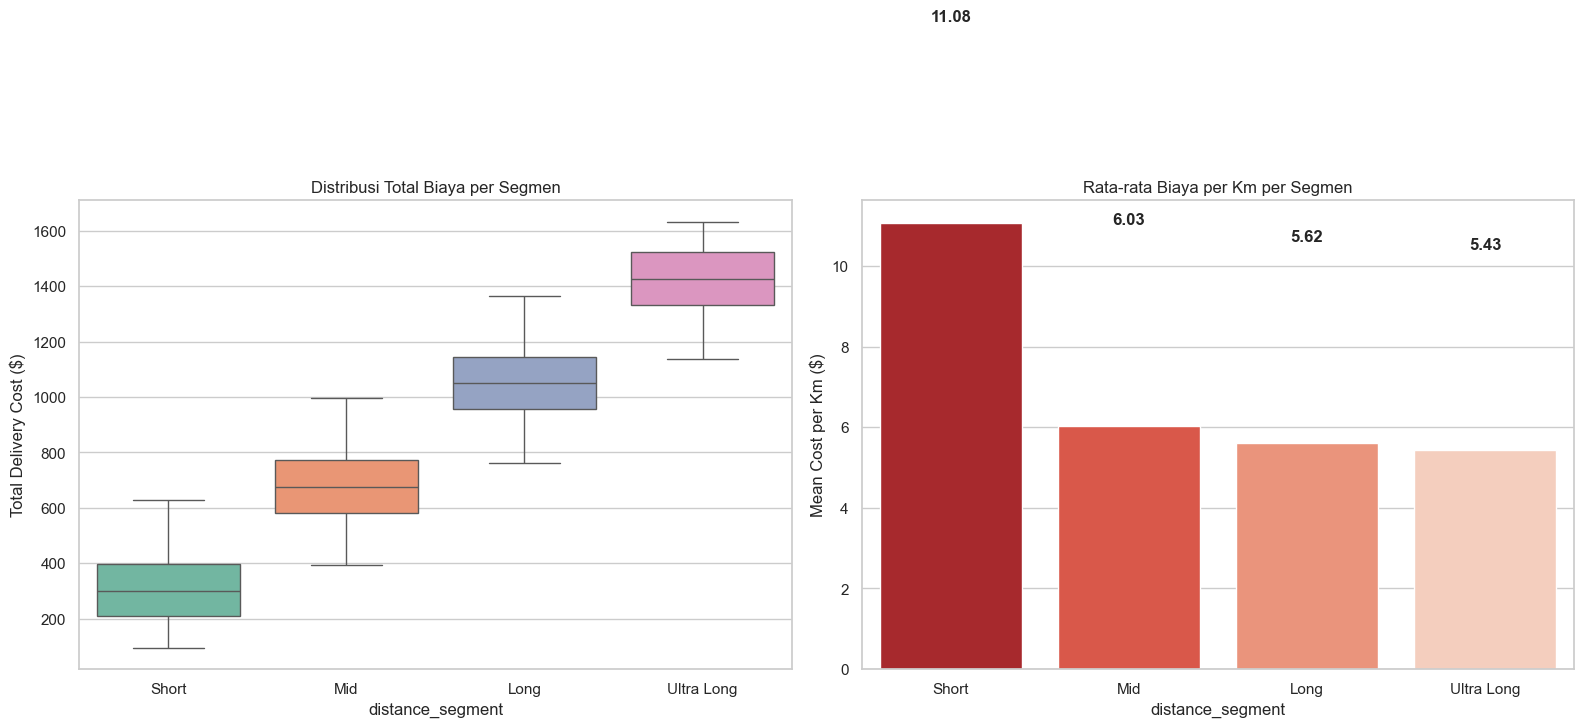

In [47]:
# Menyiapkan data dari tabel ketimpangan_biaya
plot_data = ketimpangan_biaya.reset_index()

# Buat bagan
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Boxplot 
sns.boxplot(data=df_cleaned, x='distance_segment', y='delivery_cost', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Total Biaya per Segmen')
axes[0].set_ylabel('Total Delivery Cost ($)')

# Barchart 
sns.barplot(data=plot_data, x='distance_segment', y='mean', ax=axes[1], palette='Reds_r')
axes[1].set_title('Rata-rata Biaya per Km per Segmen')
axes[1].set_ylabel('Mean Cost per Km ($)')

# Menambahkan label angka di atas bar
for i, v in enumerate(plot_data['mean']):
    axes[1].text(i, v + 5, f"{v:.2f}", ha='center', fontweight='bold')

# Mengatur tata letak agar tidak tumpang tindih
plt.tight_layout()
plt.show()

**By Delivery Status**

***Partner Vs Delivery Status***

In [48]:
partner_perfoman = (df_cleaned.groupby('delivery_partner')['delivery_status'].value_counts(normalize='index')*100).unstack()
print(partner_perfoman.sort_values(by='delayed', ascending=False))


delivery_status     delayed  delivered    failed
delivery_partner                                
shadowfax         22.441520  72.697368  4.861111
xpressbees        22.363765  71.726822  5.909413
ecom express      22.226304  73.365173  4.408523
ekart             21.920743  72.581221  5.498036
amazon logistics  21.578753  72.777573  5.643674
blue dart         21.157970  73.052180  5.789850
dhl               20.413990  73.661670  5.924340
fedex             20.404542  74.840312  4.755145
delhivery         19.813352  75.197416  4.989232


***Cuaca Vs Delivery Status***

In [49]:
weather_performan = (df_cleaned.groupby('weather_group')['delivery_status'].value_counts(normalize='index')*100).unstack()
print(weather_performan.sort_values(by='failed', ascending=False))

delivery_status    delayed  delivered    failed
weather_group                                  
Bad              28.956149  63.639975  7.403877
Good             13.664196  83.145343  3.190461


***Partner Vs Waktu (Delivered)***

In [50]:
time_performan = (deliv_stats.groupby('delivery_partner')['delivery_time_hours'].agg(['mean', 'median', 'std']).sort_values(by='mean'))
print(time_performan)

                      mean  median       std
delivery_partner                            
delhivery         5.509785     5.0  2.932181
fedex             5.531532     5.0  2.832211
dhl               5.537306     5.0  2.897266
shadowfax         5.573655     5.0  3.011586
ecom express      5.588383     5.0  2.941110
blue dart         5.591487     5.0  2.978787
xpressbees        5.595955     5.0  2.952076
ekart             5.599115     5.0  3.040595
amazon logistics  5.610745     5.0  2.894270


**By Rating**

***Rating Vs Status Deliveri***

In [51]:
rating_status = (df_cleaned.groupby('delivery_rating')['delivery_status'].value_counts(normalize=True)*100).unstack().fillna(0)
rating_status

delivery_status,delayed,delivered,failed
delivery_rating,,,
1,0.000000,0.000000,100.000000
2,88.672959,0.000000,11.327041
3,37.190369,62.809631,0.000000
4,0.000000,100.000000,0.000000
5,0.000000,100.000000,0.000000


In [52]:
rating_partner = (df_cleaned.groupby('delivery_rating')['delivery_partner'].value_counts(normalize=True)*100).unstack().fillna(0)
rating_partner

delivery_partner,amazon logistics,blue dart,delhivery,dhl,ecom express,ekart,fedex,shadowfax,xpressbees
delivery_rating,,,,,,,,,
1,11.413043,12.717391,11.086957,11.847826,9.347826,10.652174,9.673913,10.000000,13.260870
2,10.938368,11.049417,10.577457,10.438645,10.993892,11.521377,10.577457,11.965575,11.937812
3,11.068768,10.601074,11.068768,11.086090,10.930192,11.588429,11.744327,10.410532,11.501819
4,10.863624,11.123258,11.300902,11.478546,11.123258,10.808964,11.109593,10.918284,11.273572
5,10.532016,11.601462,11.330716,11.330716,10.762150,11.208880,11.601462,11.005821,10.626777


In [53]:
# Membuat tabel ringkasan 
summary = df_cleaned.groupby('delivery_partner').agg({
    'delivery_partner': 'count',           # Dominasi (Populer)
    'cost_per_km': 'median',               # Efisiensi Biaya
    'delivery_time_hours': 'median',       # Efisiensi Waktu
    'delivery_rating': 'mean'              # Bonus: Kepuasan
}).rename(columns={'delivery_partner': 'total_orders'}).sort_values(by='total_orders', ascending=False)

print("Analisa Dominasi vs Efisiensi ")
print(summary)

Analisa Dominasi vs Efisiensi 
                  total_orders  cost_per_km  delivery_time_hours  \
delivery_partner                                                   
xpressbees                2826     5.748993                  6.0   
fedex                     2818     5.758384                  6.0   
dhl                       2802     5.722578                  6.0   
ekart                     2801     5.741766                  6.0   
blue dart                 2798     5.757906                  6.0   
delhivery                 2786     5.759599                  6.0   
shadowfax                 2736     5.734588                  6.0   
ecom express              2722     5.753465                  6.0   
amazon logistics          2711     5.729392                  6.0   

                  delivery_rating  
delivery_partner                   
xpressbees               3.608988  
fedex                    3.698368  
dhl                      3.685225  
ekart                    3.655480  
blue

**By Ekpetasi waktu**

C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\716114127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=deliv_stats, x='weather_group', y='gap_time_delivery', palette='Set2')
C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\716114127.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=deliv_stats, x='delivery_partner', y='gap_time_delivery', palette='Set3')


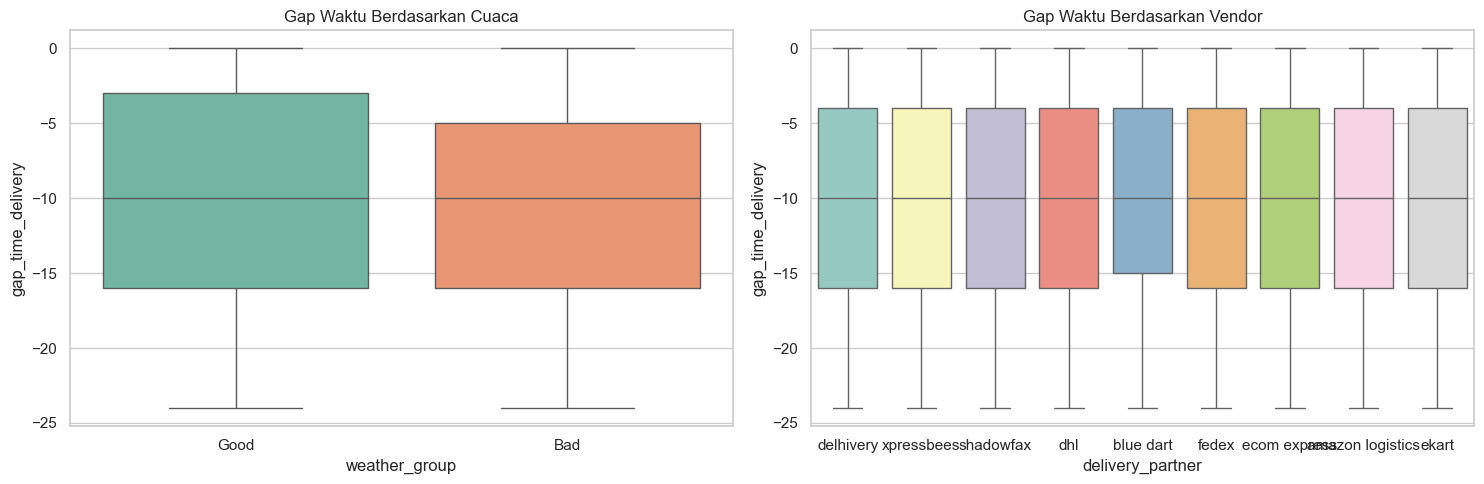

In [54]:
plt.figure(figsize=(15, 5))

# Plot 1: Pengaruh Cuaca terhadap Gap Waktu
plt.subplot(1, 2, 1)
sns.boxplot(data=deliv_stats, x='weather_group', y='gap_time_delivery', palette='Set2')
plt.title('Gap Waktu Berdasarkan Cuaca')

# Plot 2: Performa Vendor terhadap Gap Waktu
plt.subplot(1, 2, 2)
sns.boxplot(data=deliv_stats, x='delivery_partner', y='gap_time_delivery', palette='Set3')
plt.title('Gap Waktu Berdasarkan Vendor')

plt.tight_layout()
plt.show()

## Korelasi & Uji

**Uji Normalitas Data**

In [55]:
# Daftar SEMUA variabel numerik yang akan diuji
col_corr = [
    'package_weight_kg', 'delivery_cost', 'distance_km',
    'cost_per_kg', 'delivery_time_hours', 'delivery_rating',
    'cost_per_km', 'gap_time_delivery'
]


print("--- Hasil Uji Normalitas D'Agostino's K-squared Komprehensif ---")

for col in col_corr:
    # Uji normalitas
    statistic, p_value = stats.normaltest(df_cleaned[col])
    
    # Interpretasi
    is_normal = "TIDAK NORMAL (P-value <= 0.05)" if p_value <= 0.05 else "NORMAL (P-value > 0.05)"
    
    print(f"Variabel: {col}")
    print(f"  P-value: {p_value:.3e}")
    print(f"  Kesimpulan: {is_normal}")
    print("-" * 30)

--- Hasil Uji Normalitas D'Agostino's K-squared Komprehensif ---
Variabel: package_weight_kg
  P-value: 0.000e+00
  Kesimpulan: TIDAK NORMAL (P-value <= 0.05)
------------------------------
Variabel: delivery_cost
  P-value: 0.000e+00
  Kesimpulan: TIDAK NORMAL (P-value <= 0.05)
------------------------------
Variabel: distance_km
  P-value: 0.000e+00
  Kesimpulan: TIDAK NORMAL (P-value <= 0.05)
------------------------------
Variabel: cost_per_kg
  P-value: 0.000e+00
  Kesimpulan: TIDAK NORMAL (P-value <= 0.05)
------------------------------
Variabel: delivery_time_hours
  P-value: 3.729e-147
  Kesimpulan: TIDAK NORMAL (P-value <= 0.05)
------------------------------
Variabel: delivery_rating
  P-value: 0.000e+00
  Kesimpulan: TIDAK NORMAL (P-value <= 0.05)
------------------------------
Variabel: cost_per_km
  P-value: 0.000e+00
  Kesimpulan: TIDAK NORMAL (P-value <= 0.05)
------------------------------
Variabel: gap_time_delivery
  P-value: 0.000e+00
  Kesimpulan: TIDAK NORMAL (P-va

Hasil dari uji normalitas, semua kolom numerik bersifat tidak normal. Jadi, diputuskan akan melakukan uji **Non-Parametrik**

**Korelasi Spearman**

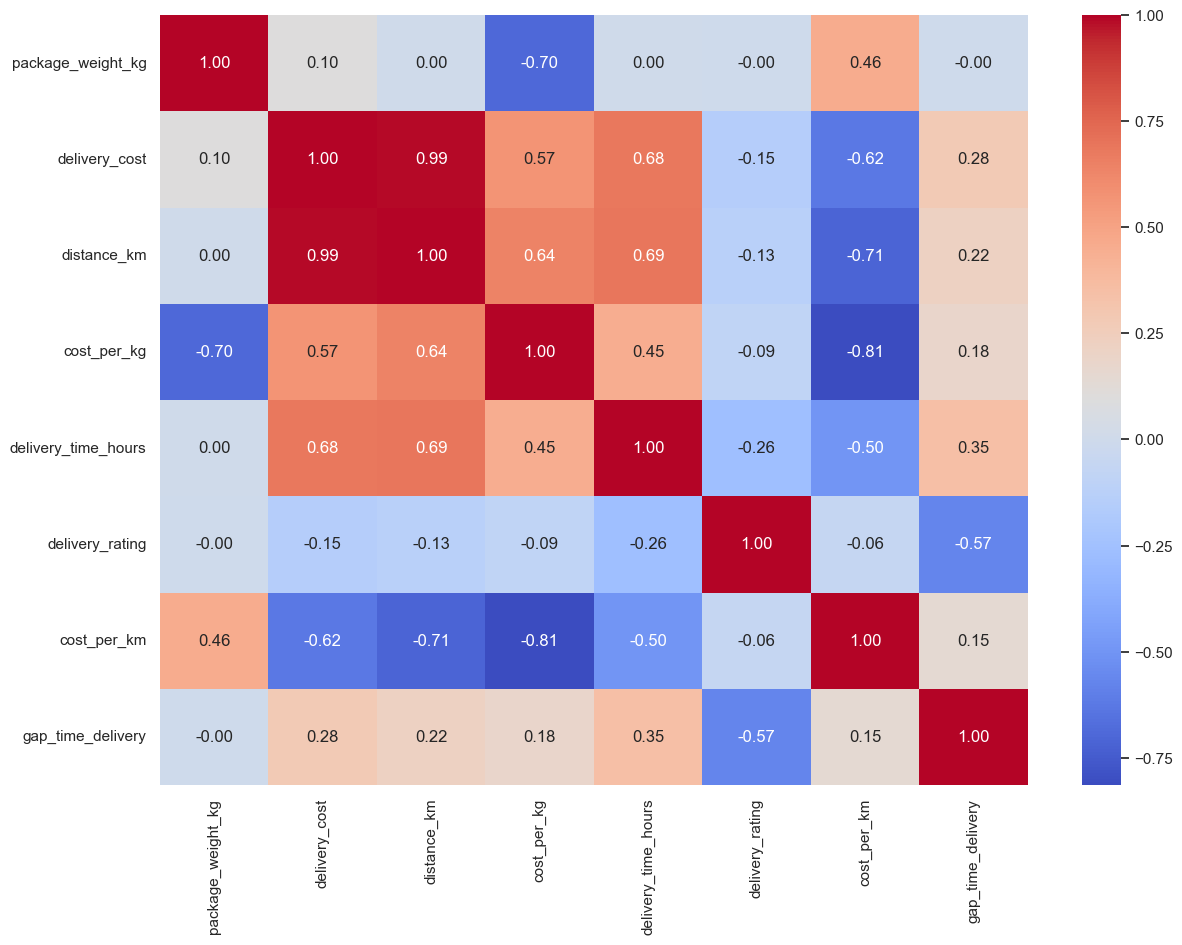

In [56]:

corr = df_cleaned[col_corr].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(corr , annot=True, cmap='coolwarm', fmt=".2f")     
plt.show()

**Uji Hipotesa**

***Terdapat variasi tarif yang signifikan antar vendor untuk segmen pengiriman yang sama (Jarak & Berat), yang menunjukkan adanya potensi overpricing pada vendor tertentu?***

In [118]:
# Kelompokkan data 'cost_per_km' berdasarkan 'delivery_partner'
grup_vendor = deliv_stats.groupby('delivery_partner')['cost_per_km'].apply(list).tolist()

# Jalankan Kruskal-Wallis menggunakan argumen * (unpacking operator)
# Bintang (*) artinya kita memasukkan semua list di dalam 'grup_vendor' sekaligus
stat, p = kruskal(*grup_vendor)

print(f"Statistik: {stat:.4f}")
print(f"P-Value: {p:.10f}")

# Interpretasi
if p < 0.05:
    print("Kesimpulan: Ada perbedaan tarif yang signifikan antar vendor (H1 Terbukti)")
else:
    print("KESIMPULAN: H1 Gagal Terbukti. Harga semua vendor mirip-mirip.")

Statistik: 5.9899
P-Value: 0.6483616888
KESIMPULAN: H1 Gagal Terbukti. Harga semua vendor mirip-mirip.


***Pengiriman jarak pendek memiliki biaya per KM yang lebih tinggi dibandingkan jarak jauh karena adanya kebijakan fixed cost atau minimum charge dari vendor?***

In [119]:

# Hitung korelasi antara Jarak dan Biaya per KM
korelasi, p_value = spearmanr(deliv_stats['distance_km'], deliv_stats['cost_per_km'])

print(f"Koefisien Korelasi Spearman: {korelasi:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < 0.05:
    if korelasi < 0:
        print("KESIMPULAN: H2 TERBUKTI. Semakin jauh jarak, biaya per KM semakin murah (Negatif).")
    else:
        print("KESIMPULAN: Ada hubungan, tapi biayanya malah naik seiring jarak (Positif).")
else:
    print("KESIMPULAN: H2 GAGAL. Tidak ada hubungan antara jarak dan efisiensi biaya per KM.")

Koefisien Korelasi Spearman: -0.7285
P-Value: 0.0000000000
KESIMPULAN: H2 TERBUKTI. Semakin jauh jarak, biaya per KM semakin murah (Negatif).


***Penggunaan kendaraan listrik (EV) memberikan biaya operasional yang lebih rendah dibandingkan kendaraan konvensional (bahan bakar fosil)?***

In [ ]:
# Buat Group kategori
mapping = {'ev bike': 'Ev', 'scooter': 'Fossil', 'van': 'Fossil','bike': 'Fossil','truck': 'Fossil','ev van': 'Ev'}
df_cleaned['energy_type'] = df_cleaned['vehicle_type'].map(mapping)

# Filter ke status delivery (Delivered)
mapp_type_status = df_cleaned[df_cleaned['delivery_status'] == 'delivered']
mapp_type_status

# Pisahkan data biaya berdasarkan kolom energy_type yang baru dibuat
cost_ev = mapp_type_status[mapp_type_status['energy_type'] == 'Ev']['delivery_cost']
cost_fossil = mapp_type_status[mapp_type_status['energy_type'] == 'Fossil']['delivery_cost']

# Jalankan Uji Mann-Whitney U
stat, p_value = mannwhitneyu(cost_ev, cost_fossil, alternative='less')

# Hitung Median untuk interpretasi
median_ev = cost_ev.median()
median_fossil = cost_fossil.median()

print(f"HASIL UJI HIPOTESIS 3")
print(f"Jumlah Data Ev    : {len(cost_ev)}")
print(f"Jumlah Data Fossil: {len(cost_fossil)}")
print("-" * 30)
print(f"Median Biaya Ev    : {median_ev:.2f}")
print(f"Median Biaya Fossil: {median_fossil:.2f}")
print(f"P-Value            : {p_value:.10f}")

# Interpretasi Akhir
if p_value < 0.05:
    if median_ev < median_fossil:
        print("\nKESIMPULAN: H3 TERBUKTI. Penggunaan kendaraan listrik (EV) secara signifikan lebih murah.")
    else:
        print("\nKESIMPULAN: Ada perbedaan signifikan, tapi EV ternyata lebih mahal (cek efisiensi operasionalnya).")
else:
    print("\nKESIMPULAN: H3 GAGAL. Tidak ada perbedaan biaya yang signifikan secara statistik.")

--- HASIL UJI HIPOTESIS 3 ---
Jumlah Data Ev    : 6123
Jumlah Data Fossil: 12208
------------------------------
Median Biaya Ev    : 803.16
Median Biaya Fossil: 787.13
P-Value            : 0.6588760299

KESIMPULAN: H3 GAGAL. Tidak ada perbedaan biaya yang signifikan secara statistik.


***Vendor dengan tarif yang lebih mahal memiliki tingkat keterlambatan (delay rate) yang lebih rendah dan rating yang lebih tinggi (Ada harga, ada rupa)?***

In [121]:


# --- UJI : TARIF VS DELAY ---
rho_delay, p_delay = spearmanr(deliv_stats['cost_per_km'], deliv_stats['is_delayed'])

# --- UJI : TARIF VS RATING ---
rho_rating, p_rating = spearmanr(deliv_stats['cost_per_km'], deliv_stats['delivery_rating'])

print(f"--- HASIL UJI HIPOTESIS 4 (Ada Harga Ada Rupa) ---")

print(f"\n1. Hubungan Tarif dengan Delay:")
print(f"   - Koefisien (Rho): {rho_delay:.4f}")
print(f"   - P-Value: {p_delay:.10f}")

print(f"\n2. Hubungan Tarif dengan Rating:")
print(f"   - Koefisien (Rho): {rho_rating:.4f}")
print(f"   - P-Value: {p_rating:.10f}")

print("\n--- KESIMPULAN STRATEGIS ---")
# Interpretasi Delay
if p_delay < 0.05 and rho_delay < 0:
    print("- Benar: Vendor mahal lebih jarang telat.")
else:
    print("- Tidak Terbukti: Harga mahal tidak menjamin ketepatan waktu.")

# Interpretasi Rating
if p_rating < 0.05 and rho_rating > 0:
    print("- Benar: Vendor mahal memiliki rating yang lebih tinggi.")
else:
    print("- Tidak Terbukti: Harga mahal tidak menjamin kepuasan pelanggan yang lebih tinggi.")

--- HASIL UJI HIPOTESIS 4 (Ada Harga Ada Rupa) ---

1. Hubungan Tarif dengan Delay:
   - Koefisien (Rho): nan
   - P-Value: nan

2. Hubungan Tarif dengan Rating:
   - Koefisien (Rho): -0.0076
   - P-Value: 0.3044448353

--- KESIMPULAN STRATEGIS ---
- Tidak Terbukti: Harga mahal tidak menjamin ketepatan waktu.
- Tidak Terbukti: Harga mahal tidak menjamin kepuasan pelanggan yang lebih tinggi.


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\1742736016.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_delay, p_delay = spearmanr(deliv_stats['cost_per_km'], deliv_stats['is_delayed'])


***Kondisi cuaca ekstrem (Stormy/Rainy) secara signifikan meningkatkan probabilitas keterlambatan pengiriman pada semua vendor?***

In [122]:

# Buat Tabel 

contingency_counts = pd.crosstab(df_cleaned['weather_group'], df_cleaned['is_delayed'])
stat_cuaca, p_cuaca, dof_cuaca, expected_cuaca = chi2_contingency(contingency_counts)

# Buat Tabel PERSENTASE
delay_rate_report = pd.crosstab(df_cleaned['weather_group'], df_cleaned['delayed'], normalize='index') * 100

# --- Tampilkan Hasil Akhir ---
print(f"--- HASIL UJI HIPOTESIS 5 (PENGARUH CUACA) ---")
print(f"Chi-Square Stat: {stat_cuaca:.4f}")
print(f"P-Value        : {p_cuaca:.10f}")

print("\n--- TABEL PERSENTASE KETERLAMBATAN (%) ---")
print(delay_rate_report)

print("\n--- KESIMPULAN STRATEGIS ---")
if p_cuaca < 0.05:
    # Ambil selisih persentase 'Yes' antara Bad dan Good
    diff = delay_rate_report.loc['Bad', 'yes'] - delay_rate_report.loc['Good', 'yes']
    print(f"- TERBUKTI: Cuaca buruk meningkatkan risiko keterlambatan sebesar {diff:.2f}%.")
else:
    print("- TIDAK TERBUKTI: Cuaca buruk tidak berdampak signifikan pada keterlambatan.")

--- HASIL UJI HIPOTESIS 5 (PENGARUH CUACA) ---
Chi-Square Stat: 1214.6289
P-Value        : 0.0000000000

--- TABEL PERSENTASE KETERLAMBATAN (%) ---
delayed               no        yes
weather_group                      
Bad            63.639975  36.360025
Good           83.145343  16.854657

--- KESIMPULAN STRATEGIS ---
- TERBUKTI: Cuaca buruk meningkatkan risiko keterlambatan sebesar 19.51%.


***Mode pengiriman Same Day memiliki risiko keterlambatan yang lebih tinggi dibandingkan mode Standard?***

In [123]:

# Buat Tabel 

contingency_counts = pd.crosstab(df_cleaned['delivery_mode'], df_cleaned['is_delayed'])
stat_mode, p_mode, dof_mode, expected_mode = chi2_contingency(contingency_counts)

# Buat Tabel PERSENTASE
delay_rate_report = pd.crosstab(df_cleaned['delivery_mode'], df_cleaned['delayed'], normalize='index') * 100

# --- Tampilkan Hasil Akhir ---
print(f" HASIL UJI HIPOTESIS 6 (MODE PENGIRIMAN) ")
print(f"Chi-Square Stat: {stat_mode:.4f}")
print(f"P-Value        : {p_mode:.10f}")

print("\nTABEL PERSENTASE KETERLAMBATAN (%)")
print(delay_rate_report)

print("\nKESIMPULAN STRATEGIS ")
if p_cuaca < 0.05:
    print(f"- TERBUKTI: Mode pengiriman berpengaruh pada keterlambatan.")
else:
    print("- TIDAK TERBUKTI: CRisiko keterlambatan sama saja antar mode.")

 HASIL UJI HIPOTESIS 6 (MODE PENGIRIMAN) 
Chi-Square Stat: 11652.3174
P-Value        : 0.0000000000

TABEL PERSENTASE KETERLAMBATAN (%)
delayed                no        yes
delivery_mode                       
express         26.215306  73.784694
same day        67.462972  32.537028
standard       100.000000   0.000000
two day         99.571565   0.428435

KESIMPULAN STRATEGIS 
- TERBUKTI: Mode pengiriman berpengaruh pada keterlambatan.


***Tidak semua vendor yang dominan (sering digunakan) merupakan vendor yang paling efisien secara biaya dan waktu?***

In [124]:
# Agregasi Efisiensi per Vendor
vendor_efficiency = deliv_stats.groupby('delivery_partner').agg(
    total_orders=('delivery_partner', 'count'),      # Dominansi (Volume)
    avg_cost_km=('cost_per_km', 'median'),        # Efisiensi Biaya Jarak
    avg_cost_kg=('cost_per_kg', 'median'),        # Efisiensi Biaya Beban
    delay_rate=('is_delayed', 'mean')           # Efisiensi Waktu
).sort_values('total_orders', ascending=False)  # Urutkan dari yang paling dominan

# Tampilkan Hasil
print(f"HASIL UJI HIPOTESIS 7")
print(" EVALUASI VENDOR: DOMINANSI VS UNIT COST & WAKTU ")
print(vendor_stats_clean := vendor_efficiency.round(4))

# Insight Singkat
top_vendor = vendor_efficiency.index[0]
cheapest_km_vendor = vendor_efficiency['avg_cost_km'].idxmin()

print(f"Vendor Paling Dominan: {top_vendor}")
print(f"Vendor Paling Efisien (per Km): {cheapest_km_vendor}")

HASIL UJI HIPOTESIS 7
 EVALUASI VENDOR: DOMINANSI VS UNIT COST & WAKTU 
                  total_orders  avg_cost_km  avg_cost_kg  delay_rate
delivery_partner                                                    
fedex                     2109       5.7379      32.8323         0.0
delhivery                 2095       5.7342      31.0251         0.0
dhl                       2064       5.7016      32.5768         0.0
blue dart                 2044       5.7393      31.3146         0.0
ekart                     2033       5.6997      32.8206         0.0
xpressbees                2027       5.7126      32.5257         0.0
ecom express              1997       5.7195      32.0688         0.0
shadowfax                 1989       5.7082      31.9467         0.0
amazon logistics          1973       5.6839      32.9078         0.0
Vendor Paling Dominan: fedex
Vendor Paling Efisien (per Km): amazon logistics


***Paket dengan berat rendah (Light Weight) memiliki efisiensi biaya per KG yang paling buruk bagi perusahaan?***

In [125]:
grup_light = deliv_stats[deliv_stats['weight_segment'] == 'Light']['cost_per_kg']
grup_mid = deliv_stats[deliv_stats['weight_segment'] == 'Mid']['cost_per_kg']
grup_heavy = deliv_stats[deliv_stats['weight_segment'] == 'Heavy']['cost_per_kg']
grup_very_heavy = deliv_stats[deliv_stats['weight_segment'] == 'Very Heavy']['cost_per_kg']

stat, p_val = kruskal(grup_light, grup_mid, grup_heavy, grup_very_heavy)

print(f"\nHasil Uji Kruskal-Wallis:")
print(f"Statistik: {stat:.4f}")
print(f"P-Value: {p_val:.10f}")

if p_val < 0.05:
    print("\nKESIMPULAN: H8 TERBUKTI. Ada perbedaan efisiensi biaya yang signifikan antar kelompok berat.")
else:
    print("\nKESIMPULAN: H8 GAGAL. Berat paket tidak memengaruhi efisiensi biaya per KG.")

    #  Agregasi untuk melihat Median Cost per KG
summary = deliv_stats.groupby('weight_segment').agg(
    jumlah_paket=('package_weight_kg', 'count'),
    median_cost_per_kg=('cost_per_kg', 'median')
).sort_values('weight_segment')

print("--- ANALISIS EFISIENSI BIAYA BERDASARKAN BERAT ---")
print(summary)


Hasil Uji Kruskal-Wallis:
Statistik: 8292.2691
P-Value: 0.0000000000

KESIMPULAN: H8 TERBUKTI. Ada perbedaan efisiensi biaya yang signifikan antar kelompok berat.
--- ANALISIS EFISIENSI BIAYA BERDASARKAN BERAT ---
                jumlah_paket  median_cost_per_kg
weight_segment                                  
Light                   4564          115.865751
Mid                     4624           41.442282
Heavy                   4573           25.582359
Very Heavy              4570           19.555024


C:\Users\DELL\AppData\Local\Temp\ipykernel_10304\2316856009.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = deliv_stats.groupby('weight_segment').agg(


In [126]:
# Save file to CSV

df_cleaned.to_csv("logistik.csv", index=False)